## Potato Disease Detection Using Deep Learning
### ResNet50-based Classification System - Complete Notebook Guide

Abstract
This study presents a deep learning approach for automated detection and classification of potato diseases using computer vision. We employ a ResNet50 architecture with transfer learning to classify potato images into five categories: Blackspot Bruising, Healthy, Brown Rot, Dry Rot, and Soft Rot.

Keywords
Deep Learning, Computer Vision, Agricultural Disease Detection, ResNet50, Transfer Learning, Image Classification



#### Used dataset: https://www.kaggle.com/datasets/sujaykapadnis/potato-disease-recognition-dataset
The augmented version was used in this research

In [6]:
# Import Libraries
import json
import math
import os
import random
from pathlib import Path
from timeit import default_timer as timer
from typing import Dict, List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler, label_binarize
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

All libraries imported successfully!
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [7]:
# Set Random Seeds and Device
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Using device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB


## Dataset Analysis


In [8]:
# Load Dataset
candidate_data_paths = [
    Path("/kaggle/input/potato-disease-recognition-dataset/Potato Disease Recognition Dataset/Augmented Images/Augmented Images"),
    Path("/kaggle/input/potato-disease-recognition-dataset/Potato Disease Recognition Dataset"),
    Path("/kaggle/input/potato-disease-recognition-dataset"),
]
image_extensions = (".jpg", ".jpeg", ".png")
class_mapping = {
    "Augmented Blackspot Bruising Disease": "Blackspot",
    "Augmented Healthy Potato": "Healthy",
    "Augmented Potato Brown Rot Disease": "Brown Rot",
    "Augmented Potato Dry Rot Disease": "Dry Rot",
    "Augmented Potato Soft Rot Disease": "Soft Rot",
}

def short_class_name(class_name: str) -> str:
    return class_mapping.get(class_name, class_name.replace("Augmented ", ""))

def looks_like_dataset_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [item for item in path.iterdir() if item.is_dir()]
    return any(any(file.suffix.lower() in image_extensions for file in class_dir.iterdir()) for class_dir in class_dirs)

data_path = next((path for path in candidate_data_paths if looks_like_dataset_root(path)), None)
if data_path is None:
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for candidate in kaggle_input.rglob("*"):
            if candidate.is_dir() and looks_like_dataset_root(candidate):
                data_path = candidate
                break

print(f"Resolved data path: {data_path}")
print(f"Path exists: {data_path.exists() if data_path else False}")
classes = sorted([item.name for item in data_path.iterdir() if item.is_dir()]) if data_path else []
print(f"Number of classes found: {len(classes)}")
if classes:
    print("Classes:", [short_class_name(class_name) for class_name in classes])
else:
    print("No class folders found. If you are on Kaggle, inspect /kaggle/input and update the dataset path if needed.")

Resolved data path: /kaggle/input/datasets/sujaykapadnis/potato-disease-recognition-dataset/Potato Disease Recognition Dataset/Augmented Images/Augmented Images
Path exists: True
Number of classes found: 5
Classes: ['Blackspot', 'Healthy', 'Brown Rot', 'Dry Rot', 'Soft Rot']


### Cell 4: Detailed Image Info DataFrame

In [9]:
print("=" * 80)
print("DETAILED IMAGE INFORMATION")
print("=" * 80)
analysis_sample_limit = 400

def list_image_paths(class_dir: Path) -> List[Path]:
    return sorted([path for path in class_dir.iterdir() if path.suffix.lower() in image_extensions])

def extract_image_features(image_path: Path) -> Dict[str, float]:
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    height, width = image_np.shape[:2]
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    gray_small = cv2.resize(gray, (96, 96), interpolation=cv2.INTER_AREA)
    glcm = graycomatrix(gray_small, [1], [0], levels=256, symmetric=True, normed=True)
    return {
        "class": image_path.parent.name,
        "file_name": image_path.name,
        "width": width,
        "height": height,
        "aspect_ratio": width / max(height, 1),
        "mean_R": float(image_np[:, :, 0].mean()),
        "mean_G": float(image_np[:, :, 1].mean()),
        "mean_B": float(image_np[:, :, 2].mean()),
        "std_R": float(image_np[:, :, 0].std()),
        "std_G": float(image_np[:, :, 1].std()),
        "std_B": float(image_np[:, :, 2].std()),
        "contrast": float(graycoprops(glcm, "contrast")[0, 0]),
        "dissimilarity": float(graycoprops(glcm, "dissimilarity")[0, 0]),
        "homogeneity": float(graycoprops(glcm, "homogeneity")[0, 0]),
        "energy": float(graycoprops(glcm, "energy")[0, 0]),
        "correlation": float(graycoprops(glcm, "correlation")[0, 0]),
    }
class_counts = {}
image_info = []
for class_name in tqdm(classes, desc="Analyzing classes"):
    paths = list_image_paths(data_path / class_name)
    class_counts[class_name] = len(paths)
    for image_path in paths[:analysis_sample_limit]:
        try:
            image_info.append(extract_image_features(image_path))
        except Exception as exc:
            print(f"Skipping {image_path.name}: {exc}")
df_info = pd.DataFrame(image_info)
print(f"Classes analyzed: {len(class_counts)}")
print(f"Total images in dataset: {sum(class_counts.values())}")
print(f"Samples analyzed for features: {len(df_info)}")
print(f"Per-class analysis cap: {analysis_sample_limit} images")
print("\nDataset Info Shape:", df_info.shape)
print("\nFirst few rows:")
print(df_info.head())
print("\nStatistical Summary:")
if df_info.empty:
    print("No image features were extracted. Check the resolved dataset path and rerun Cell 3.")
else:
    print(df_info.describe(include="all").transpose())

DETAILED IMAGE INFORMATION


Analyzing classes:   0%|          | 0/5 [00:00<?, ?it/s]

Classes analyzed: 5
Total images in dataset: 3465
Samples analyzed for features: 1705
Per-class analysis cap: 400 images

Dataset Info Shape: (1705, 16)

First few rows:
                                  class  \
0  Augmented Blackspot Bruising Disease   
1  Augmented Blackspot Bruising Disease   
2  Augmented Blackspot Bruising Disease   
3  Augmented Blackspot Bruising Disease   
4  Augmented Blackspot Bruising Disease   

                                  file_name  width  height  aspect_ratio  \
0    Blackspot Bruising Disease Aug (1).jpg    512     512           1.0   
1   Blackspot Bruising Disease Aug (10).jpg    512     512           1.0   
2  Blackspot Bruising Disease Aug (100).jpg    512     512           1.0   
3  Blackspot Bruising Disease Aug (101).jpg    512     512           1.0   
4  Blackspot Bruising Disease Aug (102).jpg    512     512           1.0   

       mean_R      mean_G      mean_B      std_R      std_G      std_B  \
0  231.573765  225.615253  203.240761  3

### Cell 5: Class Distribution & Imbalance Analysis

  Display Class  Count  Percentage  Imbalance Ratio
0       Dry Rot   1295       37.37            12.33
1     Blackspot    770       22.22             7.33
2       Healthy    735       21.21             7.00
3      Soft Rot    560       16.16             5.33
4     Brown Rot    105        3.03             1.00


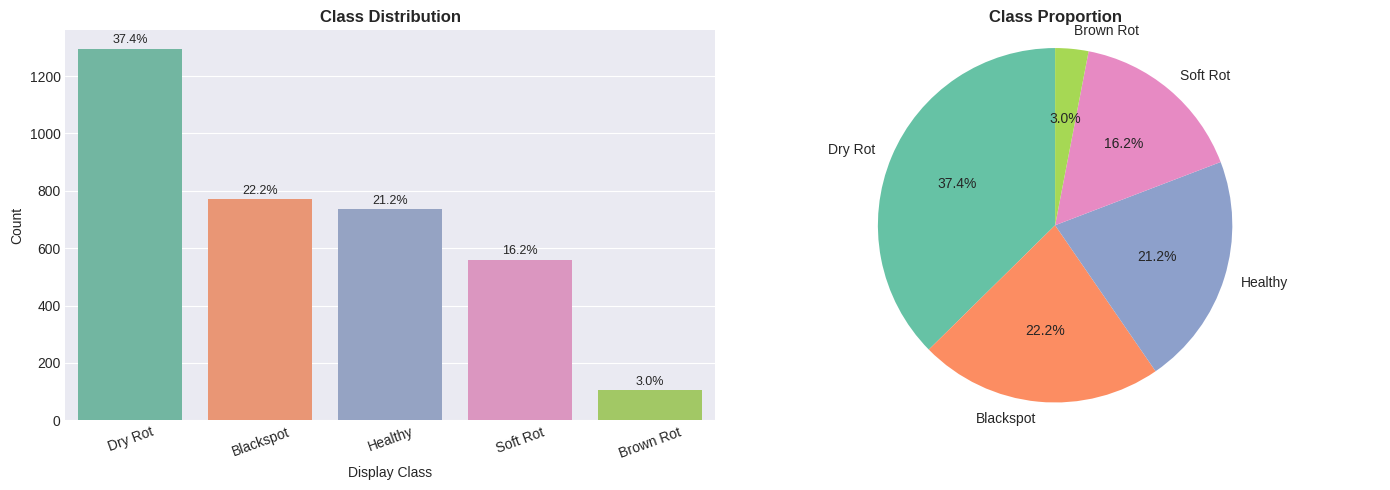

In [10]:
df_class = pd.DataFrame([{"Class": class_name, "Count": count} for class_name, count in class_counts.items()])
if df_class.empty:
    print("No class distribution data available. Run Cell 3 after confirming the dataset path.")
else:
    df_class["Display Class"] = df_class["Class"].map(short_class_name)
    df_class["Percentage"] = (df_class["Count"] / df_class["Count"].sum() * 100).round(2)
    df_class["Imbalance Ratio"] = (df_class["Count"] / df_class["Count"].min()).round(2)
    df_class = df_class.sort_values("Count", ascending=False).reset_index(drop=True)
    print(df_class[["Display Class", "Count", "Percentage", "Imbalance Ratio"]])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = sns.color_palette("Set2", len(df_class))
    sns.barplot(data=df_class, x="Display Class", y="Count", palette=colors, ax=axes[0])
    axes[0].set_title("Class Distribution", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=20)
    for idx, row in df_class.iterrows():
        axes[0].text(idx, row["Count"] + max(df_class["Count"]) * 0.015, f'{row["Percentage"]:.1f}%', ha="center", fontsize=9)
    axes[1].pie(df_class["Count"], labels=df_class["Display Class"], autopct="%1.1f%%", startangle=90, colors=colors)
    axes[1].set_title("Class Proportion", fontweight="bold")
    axes[1].axis("equal")
    plt.tight_layout()
    plt.show()

### Cell 6: RGB Color Histogram Analysis

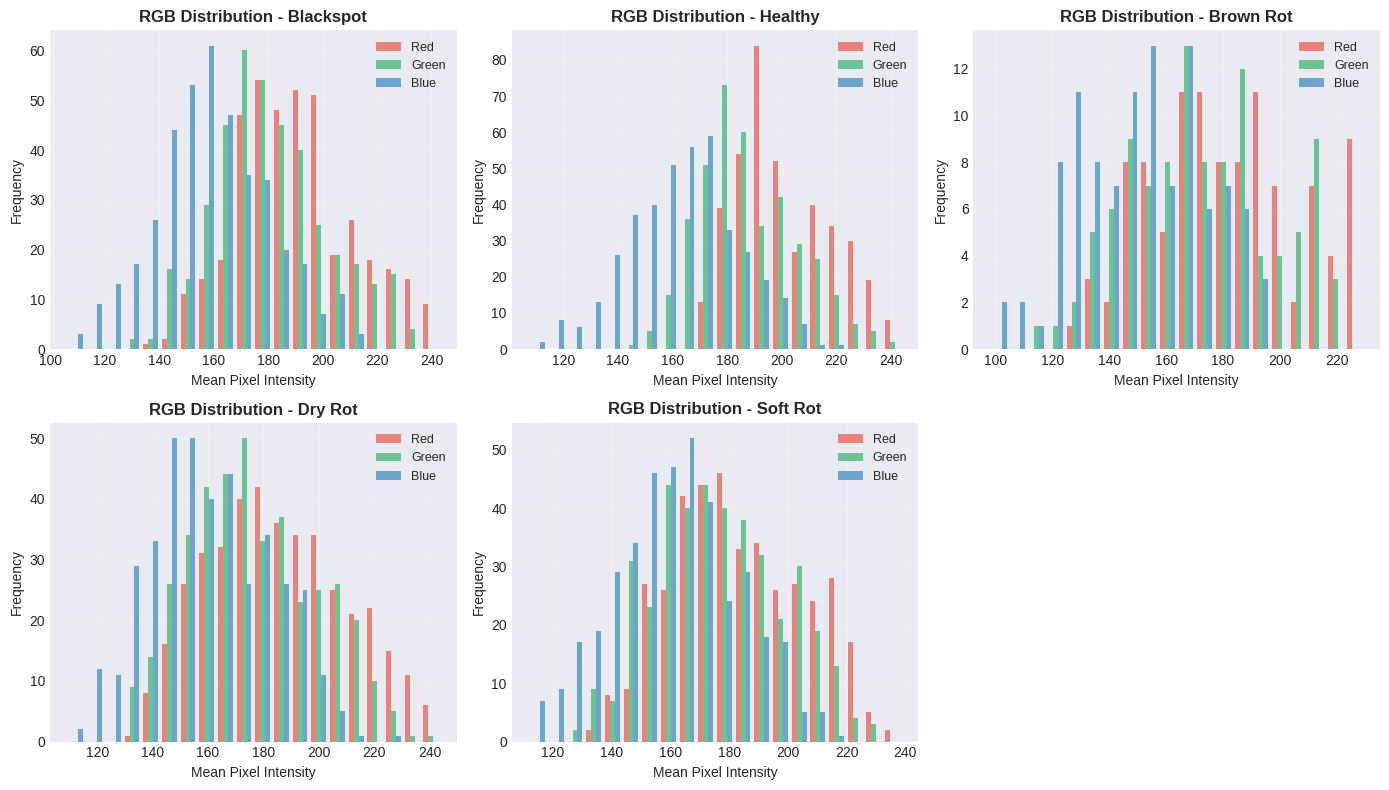

In [11]:
if df_info.empty:
    print("RGB histogram skipped because no image features are available.")
else:
    n_cols = 2 if len(classes) <= 4 else 3
    n_rows = math.ceil(len(classes) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for idx, class_name in enumerate(classes):
        class_data = df_info[df_info["class"] == class_name]
        axes[idx].hist([class_data["mean_R"], class_data["mean_G"], class_data["mean_B"]], bins=20, alpha=0.65, color=["#e74c3c", "#27ae60", "#2980b9"], label=["Red", "Green", "Blue"])
        axes[idx].set_title(f'RGB Distribution - {short_class_name(class_name)}', fontweight="bold")
        axes[idx].set_xlabel("Mean Pixel Intensity")
        axes[idx].set_ylabel("Frequency")
        axes[idx].legend(fontsize=9)
        axes[idx].grid(alpha=0.25)
    for idx in range(len(classes), len(axes)):
        axes[idx].axis("off")
    plt.tight_layout()
    plt.show()

### Cell 7: Texture Features Heatmap

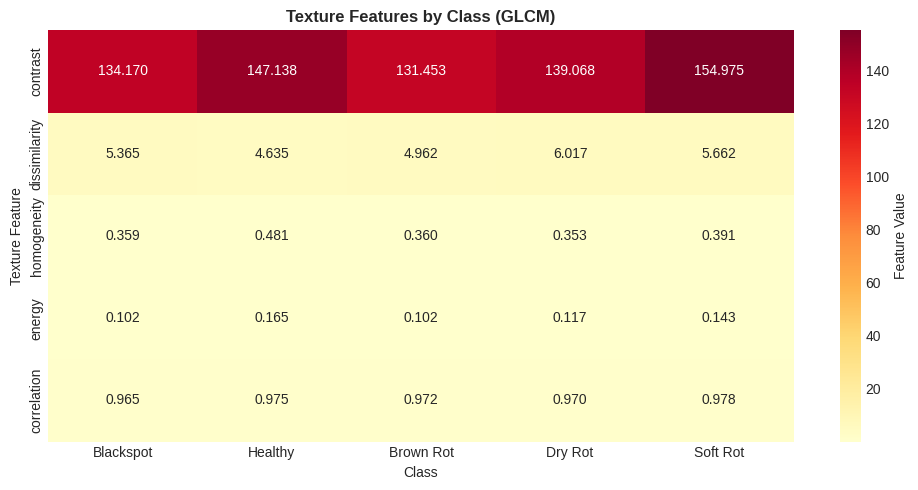

In [12]:
texture_features = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
if df_info.empty:
    print("Texture heatmap skipped because no image features are available.")
else:
    texture_df = df_info.groupby("class")[texture_features].mean()
    texture_df.index = [short_class_name(class_name) for class_name in texture_df.index]
    plt.figure(figsize=(10, 5))
    sns.heatmap(texture_df.T, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "Feature Value"})
    plt.title("Texture Features by Class (GLCM)", fontweight="bold")
    plt.xlabel("Class")
    plt.ylabel("Texture Feature")
    plt.tight_layout()
    plt.show()

### Cell 8: Principal Component Analysis (PCA)

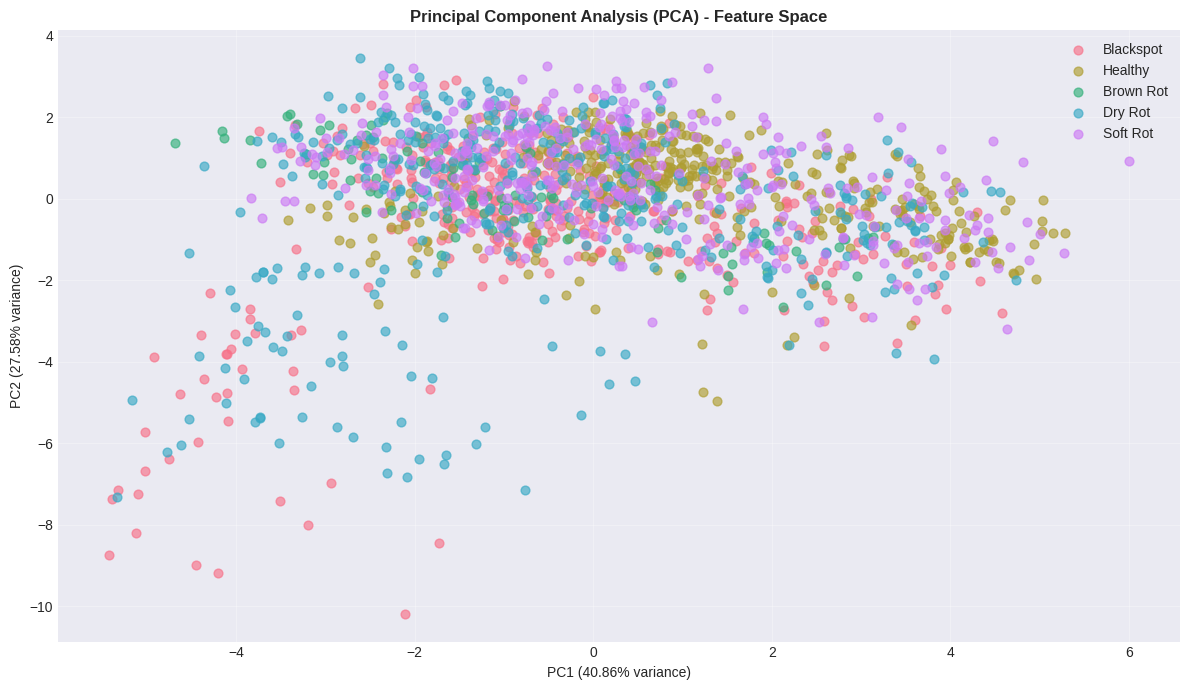

Explained variance ratio: [0.40857534 0.27582127]
Total variance explained: 68.44%


In [13]:
feature_cols = ["mean_R", "mean_G", "mean_B", "std_R", "std_G", "std_B", "contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
if df_info.empty:
    print("PCA skipped because no image features are available.")
else:
    X_features = df_info[feature_cols].values
    y_classes = df_info["class"].values
    X_scaled = StandardScaler().fit_transform(X_features)
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(X_scaled)
    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    pca_df["class"] = y_classes
    plt.figure(figsize=(12, 7))
    for color, class_name in zip(sns.color_palette("husl", len(classes)), classes):
        class_points = pca_df[pca_df["class"] == class_name]
        plt.scatter(class_points["PC1"], class_points["PC2"], label=short_class_name(class_name), alpha=0.65, s=40, color=color)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)')
    plt.title("Principal Component Analysis (PCA) - Feature Space", fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

### Cell 9: Inter-Class Feature Similarity Matrix

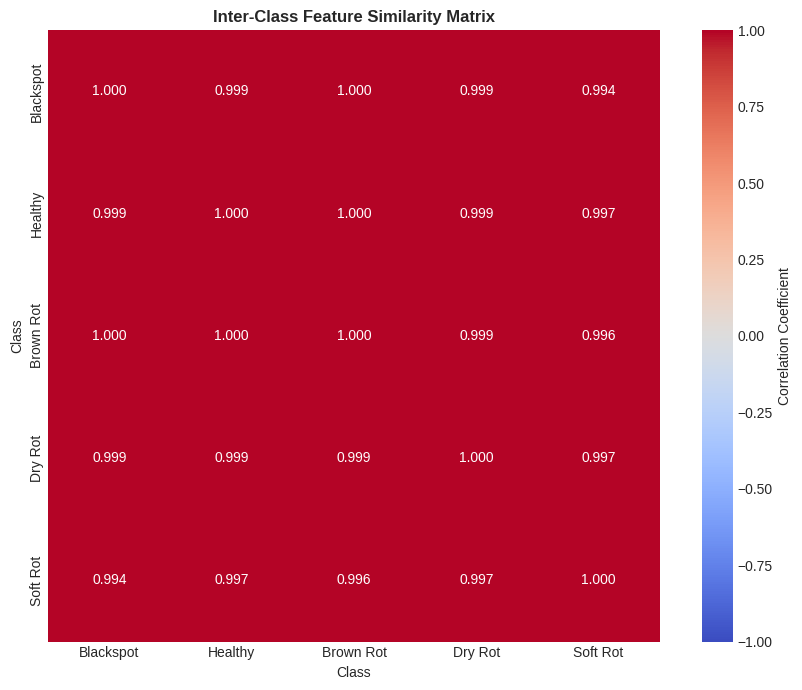

In [14]:
if df_info.empty:
    print("Inter-class similarity matrix skipped because no image features are available.")
else:
    class_features = df_info.groupby("class")[feature_cols].mean()
    class_features.index = [short_class_name(class_name) for class_name in class_features.index]
    correlation_matrix = class_features.T.corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, cbar_kws={"label": "Correlation Coefficient"})
    plt.title("Inter-Class Feature Similarity Matrix", fontweight="bold")
    plt.xlabel("Class")
    plt.ylabel("Class")
    plt.tight_layout()
    plt.show()

## Data Preprocessing


In [15]:
# Define Transformations
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count())

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Image size: 224x224
Batch size: 32


In [ ]:
# Create Data Loaders with 68% Train, 17% Validation, 15% Test Split
# (Validation is 20% of the training data)
full_dataset = datasets.ImageFolder(root=data_path, transform=val_transform)
class_names = full_dataset.classes
short_class_names = [short_class_name(class_name) for class_name in class_names]

# First split: 85% train+val, 15% test
train_val_size = int(0.85 * len(full_dataset))
test_size = len(full_dataset) - train_val_size

train_val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_val_size, test_size],

    generator=torch.Generator().manual_seed(RANDOM_SEED)print(f"Class labels: {short_class_names}")

)print(f"Test set: {len(test_dataset)} images (15%)")

print(f"Validation set: {len(val_dataset)} images (17%)")

# Second split: From train_val, split 80/20 (train/val)print(f"Training set: {len(train_dataset)} images (68%)")

train_size = int(0.8 * len(train_val_dataset))

val_size = len(train_val_dataset) - train_sizetest_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device == "cuda")

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device == "cuda")

train_dataset, val_dataset = torch.utils.data.random_split(train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=device == "cuda")

    train_val_dataset, [train_size, val_size],

    generator=torch.Generator().manual_seed(RANDOM_SEED))

Training set: 2772 images
Test set: 693 images
Class labels: ['Blackspot', 'Healthy', 'Brown Rot', 'Dry Rot', 'Soft Rot']


## Model Architecture

In [17]:
# Create ResNet50 Model
weights = torchvision.models.ResNet50_Weights.DEFAULT
model = torchvision.models.resnet50(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, len(class_names)))
model = model.to(device)
print("Base Model: ResNet50 (pre-trained)")
print(f"Output classes: {len(class_names)}")
print(f"Total parameters: {sum(parameter.numel() for parameter in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Base Model: ResNet50 (pre-trained)
Output classes: 5
Total parameters: 23,518,277


### Cell 13: Model Summary

In [18]:
def print_model_layer_summary(model_instance, input_size=(1, 3, IMG_SIZE, IMG_SIZE)):
    summary_rows = []
    hooks = []
    def register_hook(module):
        if len(list(module.children())) > 0:
            return
        def hook(module, inputs, output):
            output_shape = list(output.shape) if hasattr(output, "shape") else str(type(output))
            params = sum(parameter.numel() for parameter in module.parameters(recurse=False))
            summary_rows.append((f"{module.__class__.__name__}-{len(summary_rows) + 1}", output_shape, params))
        hooks.append(module.register_forward_hook(hook))
    was_training = model_instance.training
    model_instance.eval()
    model_instance.apply(register_hook)
    with torch.inference_mode():
        _ = model_instance(torch.randn(*input_size).to(device))
    for hook in hooks:
        hook.remove()
    if was_training:
        model_instance.train()
    print(f"{'Layer (type)':<32} {'Output Shape':<24} {'Param #':>12}")
    print("-" * 74)
    total_params = 0
    for layer_name, output_shape, params in summary_rows:
        print(f"{layer_name:<32} {str(output_shape):<24} {params:>12,}")
        total_params += params
    print("-" * 74)
    print(f"{'Total params':<32} {'':<24} {total_params:>12,}")
print_model_layer_summary(model)

Layer (type)                     Output Shape                  Param #
--------------------------------------------------------------------------
Conv2d-1                         [1, 64, 112, 112]               9,408
BatchNorm2d-2                    [1, 64, 112, 112]                 128
ReLU-3                           [1, 64, 112, 112]                   0
MaxPool2d-4                      [1, 64, 56, 56]                     0
Conv2d-5                         [1, 64, 56, 56]                 4,096
BatchNorm2d-6                    [1, 64, 56, 56]                   128
ReLU-7                           [1, 64, 56, 56]                     0
Conv2d-8                         [1, 64, 56, 56]                36,864
BatchNorm2d-9                    [1, 64, 56, 56]                   128
ReLU-10                          [1, 64, 56, 56]                     0
Conv2d-11                        [1, 256, 56, 56]               16,384
BatchNorm2d-12                   [1, 256, 56, 56]                  512
Co

In [19]:
# Training Configuration
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print("Optimizer: Adam")

Epochs: 30
Learning rate: 0.001
Optimizer: Adam


## Model Training

In [20]:
# Training Functions
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
    return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)
            test_loss += loss.item()
            preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
            test_acc += (preds == y).sum().item() / len(preds)
    return test_loss / len(dataloader), test_acc / len(dataloader)
print("Training functions defined!")

Training functions defined!


In [ ]:
# Train Model
results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_times": []}
print(f"TRAINING STARTED - {NUM_EPOCHS} EPOCHS")
start_time = timer()
best_val_acc = 0
for epoch in tqdm(range(NUM_EPOCHS), desc="Training Progress"):
    epoch_start = timer()
    train_loss, train_acc = train_step(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = test_step(model, val_loader, loss_fn, device)
    scheduler.step()
    epoch_time = timer() - epoch_start
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["val_loss"].append(val_loss)
    results["val_acc"].append(val_acc)
    results["epoch_times"].append(epoch_time)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "val_acc": val_acc}, "best_model_checkpoint.pth")
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == NUM_EPOCHS - 1:
        print(f"\nEpoch {epoch + 1:03d}/{NUM_EPOCHS} | Time: {epoch_time:.2f}s")
        print(f"  Train: Loss {train_loss:.4f} | Acc {train_acc * 100:.2f}%")
        print(f"  Val:   Loss {val_loss:.4f} | Acc {val_acc * 100:.2f}%")
total_time = timer() - start_time
print(f"\nTotal time: {total_time:.2f}s ({total_time / 60:.2f} min)")
print(f"Best validation accuracy: {best_val_acc * 100:.2f}%")
with open("training_results.json", "w") as file:
    json.dump(results, file, indent=4)

TRAINING STARTED - 30 EPOCHS


Training Progress:   0%|          | 0/30 [00:00<?, ?it/s]


Epoch 001/30 | Time: 31.76s
  Train: Loss 0.4370 | Acc 84.64%
  Test:  Loss 0.4111 | Acc 87.98%

Epoch 005/30 | Time: 34.58s
  Train: Loss 0.0918 | Acc 97.12%
  Test:  Loss 0.2049 | Acc 93.11%

Epoch 010/30 | Time: 34.66s
  Train: Loss 0.0679 | Acc 98.38%
  Test:  Loss 0.0611 | Acc 97.59%

Epoch 015/30 | Time: 34.76s
  Train: Loss 0.0026 | Acc 99.96%
  Test:  Loss 0.0182 | Acc 99.15%

Epoch 020/30 | Time: 34.66s
  Train: Loss 0.0010 | Acc 100.00%
  Test:  Loss 0.0173 | Acc 99.01%

Epoch 025/30 | Time: 34.66s
  Train: Loss 0.0015 | Acc 99.96%
  Test:  Loss 0.0150 | Acc 99.29%

Epoch 030/30 | Time: 34.73s
  Train: Loss 0.0010 | Acc 100.00%
  Test:  Loss 0.0164 | Acc 99.29%

Total time: 1037.93s (17.30 min)
Best accuracy: 99.43%


### Cell 15: Plot Training Curves

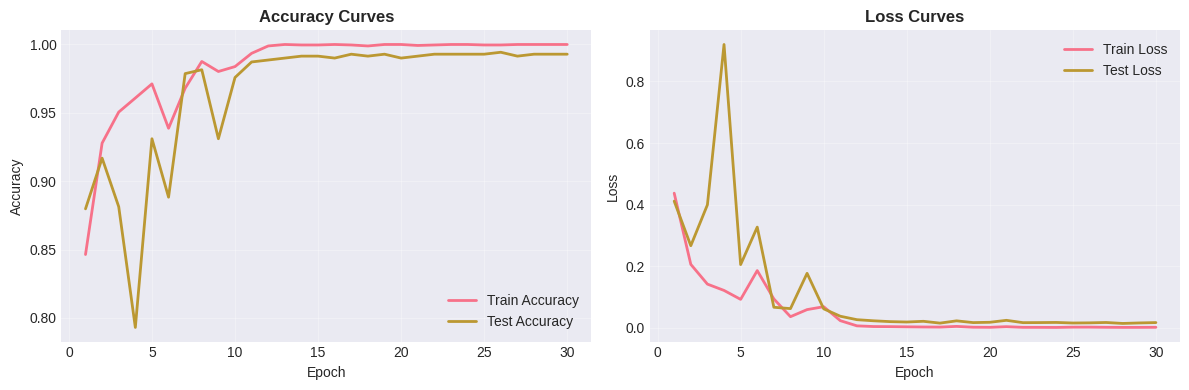

In [ ]:
def plot_training_curves(training_results):
    epochs = range(1, len(training_results["train_loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, training_results["train_acc"], label="Train Accuracy", linewidth=2)
    plt.plot(epochs, training_results["val_acc"], label="Validation Accuracy", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curves", fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, training_results["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(epochs, training_results["val_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves", fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_training_curves(results)

Testing:   0%|          | 0/22 [00:00<?, ?it/s]

Test Accuracy: 99.42%
Avg Precision: 0.9951
Avg Recall: 0.9932
Avg F1-Score: 0.9941


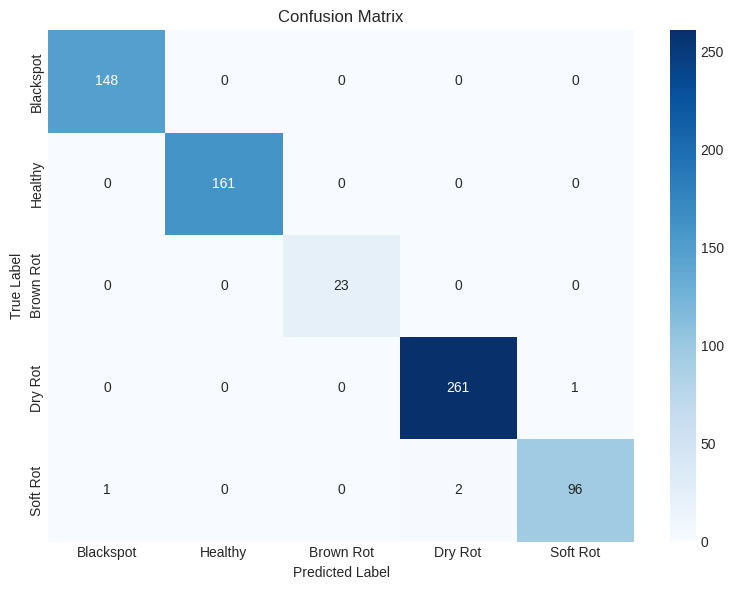

In [23]:
# Load Best Model and Evaluate
checkpoint = torch.load("best_model_checkpoint.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.inference_mode():
    for X, y in tqdm(test_loader, desc="Testing"):
        X, y = X.to(device), y.to(device)
        logits = model(X)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
test_accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
avg_precision = np.mean(precision)
avg_recall = np.mean(recall)
avg_f1 = np.mean(f1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Avg Precision: {avg_precision:.4f}")
print(f"Avg Recall: {avg_recall:.4f}")
print(f"Avg F1-Score: {avg_f1:.4f}")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short_class_names, yticklabels=short_class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Cell 18: Classification Report

In [24]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=short_class_names, digits=4, zero_division=0))

Classification Report:

              precision    recall  f1-score   support

   Blackspot     0.9933    1.0000    0.9966       148
     Healthy     1.0000    1.0000    1.0000       161
   Brown Rot     1.0000    1.0000    1.0000        23
     Dry Rot     0.9924    0.9962    0.9943       262
    Soft Rot     0.9897    0.9697    0.9796        99

    accuracy                         0.9942       693
   macro avg     0.9951    0.9932    0.9941       693
weighted avg     0.9942    0.9942    0.9942       693



### Cell 20: Precision-Recall Curves

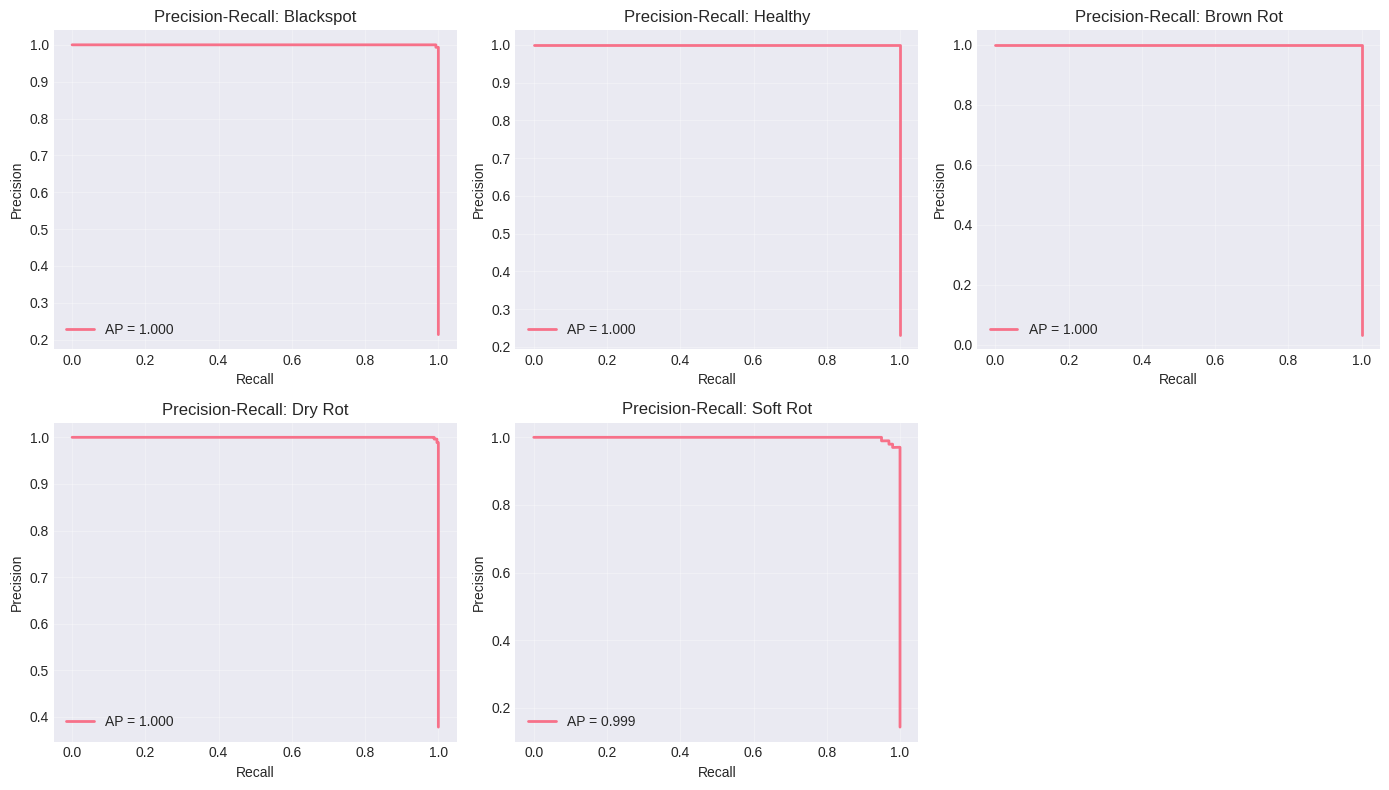

In [25]:
y_true_bin = label_binarize(all_labels, classes=range(len(class_names)))
n_cols = 2 if len(class_names) <= 4 else 3
n_rows = math.ceil(len(class_names) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()
for index, class_name in enumerate(short_class_names):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_bin[:, index], all_probs[:, index])
    avg_precision_score = average_precision_score(y_true_bin[:, index], all_probs[:, index])
    axes[index].plot(recall_curve, precision_curve, linewidth=2, label=f"AP = {avg_precision_score:.3f}")
    axes[index].set_title(f"Precision-Recall: {class_name}")
    axes[index].set_xlabel("Recall")
    axes[index].set_ylabel("Precision")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
for index in range(len(class_names), len(axes)):
    axes[index].axis("off")
plt.tight_layout()
plt.show()

### Cell 21: ROC Curves

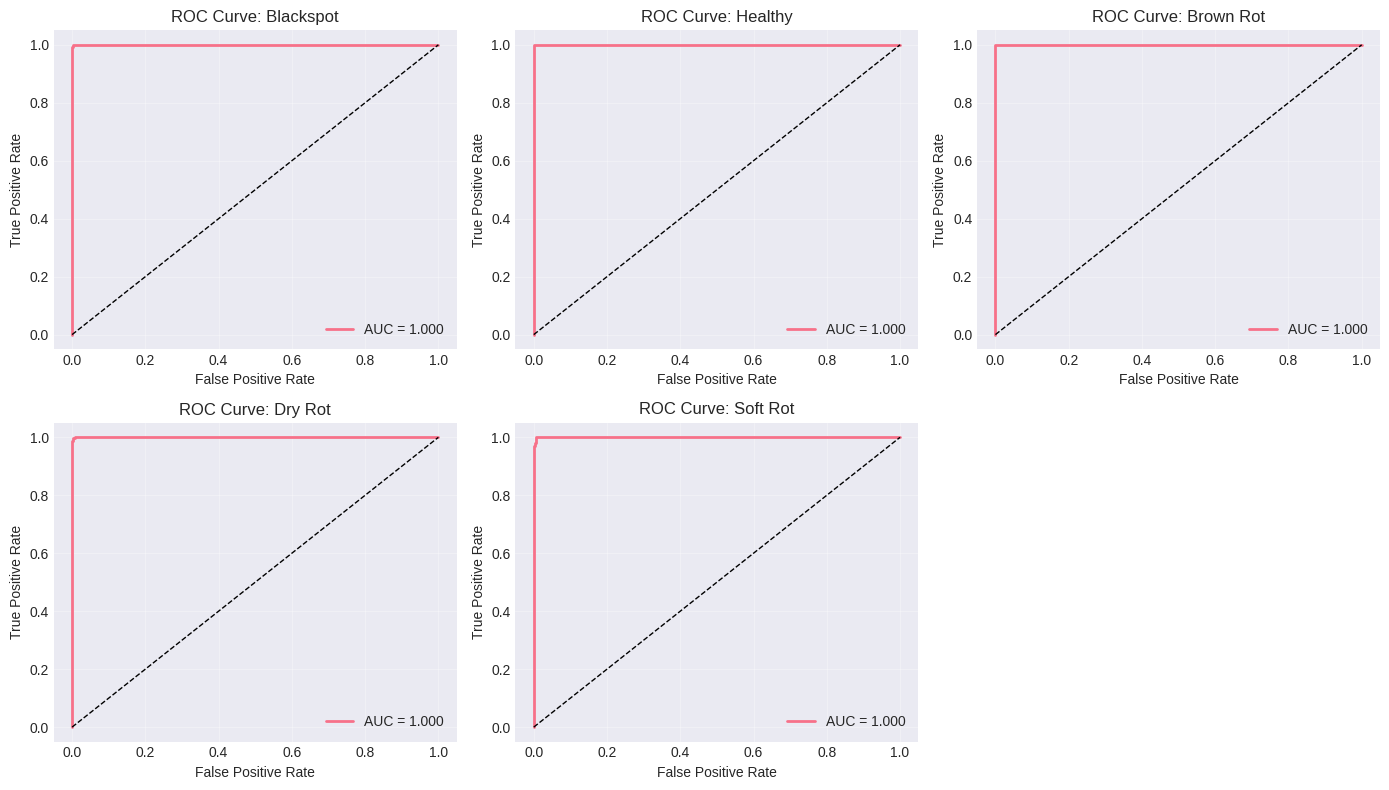

In [26]:
n_cols = 2 if len(class_names) <= 4 else 3
n_rows = math.ceil(len(class_names) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()
for index, class_name in enumerate(short_class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, index], all_probs[:, index])
    roc_auc = auc(fpr, tpr)
    axes[index].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    axes[index].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[index].set_title(f"ROC Curve: {class_name}")
    axes[index].set_xlabel("False Positive Rate")
    axes[index].set_ylabel("True Positive Rate")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
for index in range(len(class_names), len(axes)):
    axes[index].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Save Complete Model
model_save_path = "potato_disease_resnet50.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "short_class_names": short_class_names,
    "class_mapping": class_mapping,
    "model_architecture": "resnet50",
    "num_classes": len(class_names),
    "best_validation_accuracy": best_val_acc,
    "test_accuracy": test_accuracy,
    "training_epochs": NUM_EPOCHS,
    "img_size": IMG_SIZE,
    "training_results": results,
}, model_save_path)
print(f"Model saved to '{model_save_path}'")
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"File size: {os.path.getsize(model_save_path) / (1024 * 1024):.2f} MB")

Model saved to 'potato_disease_resnet50.pth'
File size: 90.03 MB


## ONNX Export


In [30]:
!pip install onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 11.8 MB/s eta 0:00:00


In [31]:
# Export to ONNX
def convert_model_to_onnx(model_instance, class_names, output_path="potato_disease_resnet.onnx"):
    import onnx
    model_instance.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    torch.onnx.export(model_instance, dummy_input, output_path, export_params=True, opset_version=11, do_constant_folding=True, input_names=["input"], output_names=["output"], dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}})
    class_names_path = output_path.replace(".onnx", "_classes.json")
    with open(class_names_path, "w") as file:
        json.dump(class_names, file)
    transform_info = {"input_size": 224, "mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]}
    transform_path = output_path.replace(".onnx", "_transform.json")
    with open(transform_path, "w") as file:
        json.dump(transform_info, file)
    print(f"ONNX model saved: {output_path}")
    print(f"Class names saved: {class_names_path}")
    print(f"Transform info saved: {transform_path}")
    onnx_model = onnx.load(output_path)
    onnx.checker.check_model(onnx_model)
    print("ONNX model verified successfully")
    print(f"File size: {os.path.getsize(output_path) / (1024 * 1024):.2f} MB")
    print("Model can now be used without PyTorch")
convert_model_to_onnx(model, class_names, "resnet_potato_tuber_model.onnx")

W0329 18:08:40.802000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0329 18:08:41.555000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0329 18:08:41.557000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

Applied 107 of general pattern rewrite rules.
ONNX model saved: resnet_potato_tuber_model.onnx
Class names saved: resnet_potato_tuber_model_classes.json
Transform info saved: resnet_potato_tuber_model_transform.json
ONNX model verified successfully
File size: 0.22 MB
Model can now be used without PyTorch


In [32]:
# Create ONNX Runtime Session
import onnxruntime as ort
class ONNXPotatoDiseaseModel:
    def __init__(self, model_path="resnet_potato_tuber_model.onnx"):
        if not os.path.exists(model_path):
            fallback_path = "potato_disease_resnet.onnx"
            if not os.path.exists(fallback_path):
                raise FileNotFoundError(f"Model file not found: {model_path}")
            model_path = fallback_path
        self.session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
        self.input_name = self.session.get_inputs()[0].name
        class_names_path = model_path.replace(".onnx", "_classes.json")
        if os.path.exists(class_names_path):
            with open(class_names_path, "r") as file:
                self.class_names = json.load(file)
        else:
            self.class_names = class_names
        transform_path = model_path.replace(".onnx", "_transform.json")
        if os.path.exists(transform_path):
            with open(transform_path, "r") as file:
                self.transform_info = json.load(file)
        else:
            self.transform_info = {"input_size": 224, "mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]}
        self.display_class_names = [short_class_name(class_name) for class_name in self.class_names]
        print(f"Model loaded: {model_path}")
        print(f"Input name: {self.input_name}")
        print(f"Classes: {self.display_class_names}")
        print(f"Input size: {self.transform_info['input_size']}")
    def preprocess_image(self, image_path: str):
        image = Image.open(image_path).convert("RGB")
        target_size = self.transform_info["input_size"]
        image_resized = image.resize((target_size, target_size))
        image_array = np.array(image_resized).astype(np.float32) / 255.0
        mean = np.array(self.transform_info["mean"], dtype=np.float32).reshape(1, 1, 3)
        std = np.array(self.transform_info["std"], dtype=np.float32).reshape(1, 1, 3)
        image_array = (image_array - mean) / std
        image_array = np.transpose(image_array, (2, 0, 1))
        image_array = np.expand_dims(image_array, axis=0).astype(np.float32)
        return image_array, image
    def predict(self, image_path: str):
        input_data, original_image = self.preprocess_image(image_path)
        output = self.session.run(None, {self.input_name: input_data})[0]
        probabilities = torch.softmax(torch.tensor(output), dim=1).numpy()[0]
        predicted_index = int(np.argmax(probabilities))
        confidence = float(probabilities[predicted_index])
        predicted_class = self.class_names[predicted_index]
        predicted_display_name = self.display_class_names[predicted_index]
        return predicted_class, predicted_display_name, confidence, probabilities, original_image
try:
    onnx_model = ONNXPotatoDiseaseModel("resnet_potato_tuber_model.onnx")
    print("ONNX model loaded successfully")
except Exception as exc:
    onnx_model = None
    print(f"Error loading ONNX model: {exc}")
    print("Please make sure the ONNX export cell has been executed successfully.")

Model loaded: resnet_potato_tuber_model.onnx
Input name: input
Classes: ['Blackspot', 'Healthy', 'Brown Rot', 'Dry Rot', 'Soft Rot']
Input size: 224
ONNX model loaded successfully


## ONNX Testing

Testing loaded model with sample image: /kaggle/input/datasets/sujaykapadnis/potato-disease-recognition-dataset/Potato Disease Recognition Dataset/Augmented Images/Augmented Images/Augmented Blackspot Bruising Disease/Blackspot Bruising Disease Aug (1).jpg


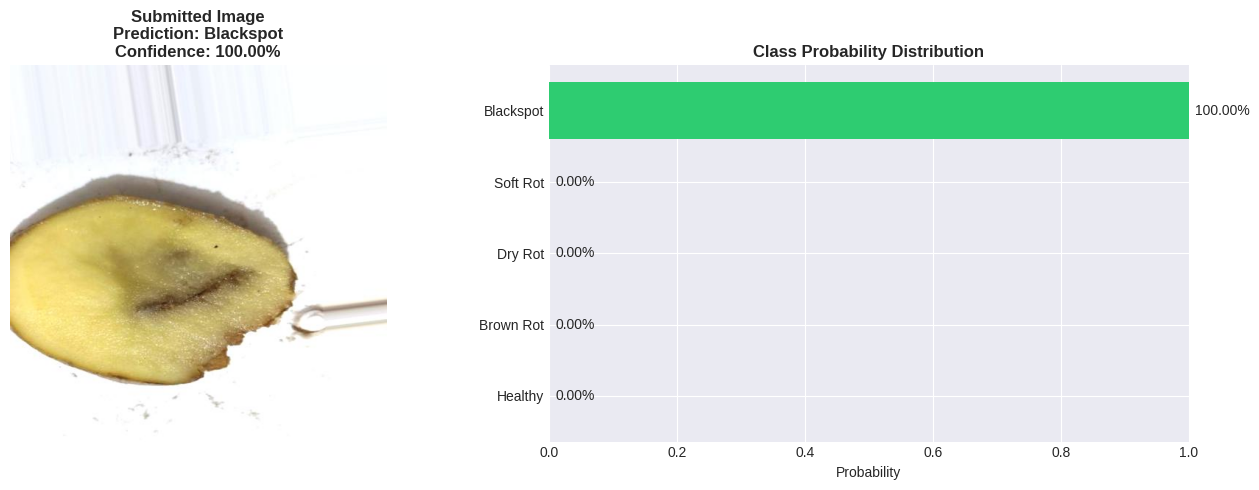

Predicted class: Blackspot
Confidence: 100.00%
All class probabilities:
  Blackspot: 1.0000
  Healthy: 0.0000
  Brown Rot: 0.0000
  Dry Rot: 0.0000
  Soft Rot: 0.0000


In [33]:
# Test Using Loaded Model
def predict_with_onnx(image_path, model_instance):
    if model_instance is None or not hasattr(model_instance, "predict"):
        print("A loaded ONNX model is required before running inference.")
        return None
    return model_instance.predict(image_path)

def visualize_prediction(image_path: str, model_instance):
    prediction = predict_with_onnx(image_path, model_instance)
    if prediction is None:
        return None
    predicted_class, predicted_display_name, confidence, probabilities, original_image = prediction
    display_labels = model_instance.display_class_names
    sort_indices = np.argsort(probabilities)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(original_image)
    axes[0].axis("off")
    axes[0].set_title(f"Submitted Image\nPrediction: {predicted_display_name}\nConfidence: {confidence:.2%}", fontweight="bold")
    bar_colors = ["#95a5a6"] * len(display_labels)
    bar_colors[int(np.argmax(probabilities))] = "#2ecc71"
    axes[1].barh([display_labels[index] for index in sort_indices], probabilities[sort_indices], color=[bar_colors[index] for index in sort_indices])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Class Probability Distribution", fontweight="bold")
    for bar_index, prob_index in enumerate(sort_indices):
        axes[1].text(probabilities[prob_index] + 0.01, bar_index, f"{probabilities[prob_index]:.2%}", va="center")
    plt.tight_layout()
    plt.show()
    print(f"Predicted class: {predicted_display_name}")
    print(f"Confidence: {confidence:.2%}")
    print("All class probabilities:")
    for label, probability in zip(display_labels, probabilities):
        print(f"  {label}: {probability:.4f}")
    return predicted_class, predicted_display_name, confidence, probabilities
sample_test_image = None
for class_name in classes:
    class_dir = data_path / class_name
    class_images = sorted([path for path in class_dir.iterdir() if path.suffix.lower() in image_extensions])
    if class_images:
        sample_test_image = str(class_images[0])
        break
if sample_test_image:
    print(f"Testing loaded model with sample image: {sample_test_image}")
    visualize_prediction(sample_test_image, onnx_model)
else:
    print("No sample image found in the dataset path")

In [34]:
# Test ONNX on Full Test Set
def evaluate_onnx_model(model_instance, test_loader):
    print("\nONNX MODEL - FULL TEST SET EVALUATION")
    print("=" * 50)
    if model_instance is None:
        print("Model not loaded. Please run the ONNX export and load cells first.")
        return None, None, None
    dataset = test_loader.dataset
    if isinstance(dataset, torch.utils.data.Subset):
        base_dataset = dataset.dataset
        sample_indices = dataset.indices
    else:
        base_dataset = dataset
        sample_indices = list(range(len(dataset.samples)))
    onnx_preds, onnx_labels = [], []
    inference_times = []
    for sample_index in tqdm(sample_indices, desc="ONNX Evaluation"):
        image_path, label = base_dataset.samples[sample_index]
        start = timer()
        _, predicted_display_name, _, _, _ = model_instance.predict(image_path)
        inference_times.append((timer() - start) * 1000)
        predicted_index = model_instance.display_class_names.index(predicted_display_name)
        onnx_preds.append(predicted_index)
        onnx_labels.append(label)
    onnx_accuracy = accuracy_score(onnx_labels, onnx_preds)
    avg_inference_time = float(np.mean(inference_times))
    total_samples = len(onnx_labels)
    print(f"Samples evaluated: {total_samples}")
    print(f"ONNX Accuracy: {onnx_accuracy * 100:.2f}%")
    print(f"Average inference time: {avg_inference_time:.2f} ms/image")
    return onnx_accuracy, avg_inference_time, total_samples
onnx_accuracy, avg_inference_time, total_samples = evaluate_onnx_model(onnx_model, test_loader)


ONNX MODEL - FULL TEST SET EVALUATION


ONNX Evaluation:   0%|          | 0/693 [00:00<?, ?it/s]

Samples evaluated: 693
ONNX Accuracy: 98.85%
Average inference time: 50.88 ms/image


## Final Summary

In [ ]:
# Generate Final Report
onnx_vars_available = "onnx_accuracy" in globals() and onnx_accuracy is not None
accuracy_diff = abs(test_accuracy - onnx_accuracy) if onnx_vars_available else None
summary_report = f"""
===============================================================================
                    POTATO DISEASE DETECTION - FINAL REPORT
===============================================================================

PROJECT OVERVIEW:
-----------------
Objective: Automated potato disease detection using deep learning
Model: ResNet50 with transfer learning
Dataset: Augmented potato disease images

DATASET STATISTICS:
-------------------
Total Images: {len(full_dataset)}
Classes: {len(class_names)}
Training Set: {len(train_dataset)} ({len(train_dataset) / len(full_dataset) * 100:.1f}%)
Validation Set: {len(val_dataset)} ({len(val_dataset) / len(full_dataset) * 100:.1f}%)
Test Set: {len(test_dataset)} ({len(test_dataset) / len(full_dataset) * 100:.1f}%)

TRAINING CONFIGURATION:
-----------------------
Epochs: {NUM_EPOCHS}
Batch Size: {BATCH_SIZE}
Learning Rate: {LEARNING_RATE}
Optimizer: Adam
Device: {device}
Total Time: {total_time:.2f}s ({total_time / 60:.2f} min)

PYTORCH MODEL PERFORMANCE:
--------------------------
Best Validation Accuracy: {best_val_acc * 100:.2f}%
Test Accuracy: {test_accuracy * 100:.2f}%
Avg Precision: {avg_precision:.4f}
Avg Recall: {avg_recall:.4f}
Avg F1-Score: {avg_f1:.4f}
"""
if onnx_vars_available:
    summary_report += f"""
ONNX MODEL PERFORMANCE:
-----------------------
Test Accuracy: {onnx_accuracy * 100:.2f}%
Avg Inference Time: {avg_inference_time:.2f} ms/image
Consistency with PyTorch: {accuracy_diff:.6f} difference
"""
else:
    summary_report += """
ONNX MODEL PERFORMANCE:
-----------------------
ONNX model exported successfully but not evaluated in this session.
Model file: resnet_potato_tuber_model.onnx
"""
summary_report += f"""
FILES GENERATED:
----------------
1. best_model_checkpoint.pth - Best validation checkpoint
2. potato_disease_resnet50.pth - Complete PyTorch model
3. resnet_potato_tuber_model.onnx - ONNX deployment model
4. resnet_potato_tuber_model_classes.json - Class names
5. resnet_potato_tuber_model_transform.json - Preprocessing info
6. training_results.json - Training history
7. final_report.txt - This summary report

CONCLUSIONS:
------------
The ResNet50 model achieves {test_accuracy * 100:.1f}% accuracy on the held-out test set.
Best validation accuracy during training was {best_val_acc * 100:.1f}%.
The ONNX export enables efficient deployment on systems without PyTorch.
The model is ready for agricultural deployment for real-time disease detection.

METHODOLOGY NOTE:
-----------------
Data split: 68% training | 17% validation | 15% test
Validation set was used to guide model selection during training.
Test set was held completely separate for unbiased final evaluation.

NEXT STEPS:
-----------
1. Download all generated files from Kaggle
2. On your PC, install: pip install onnxruntime pillow numpy
3. Use the ONNX model with the provided preprocessing functions
4. Test with new potato images

===============================================================================
"""
print(summary_report)
with open("final_report.txt", "w") as file:
    file.write(summary_report)
print("\nFinal report saved to 'final_report.txt'")


                    POTATO DISEASE DETECTION - FINAL REPORT

PROJECT OVERVIEW:
-----------------
Objective: Automated potato disease detection using deep learning
Model: ResNet50 with transfer learning
Dataset: Augmented potato disease images

DATASET STATISTICS:
-------------------
Total Images: 3465
Classes: 5
Training Set: 2772 (80.0%)
Test Set: 693 (20.0%)

TRAINING CONFIGURATION:
-----------------------
Epochs: 30
Batch Size: 32
Learning Rate: 0.001
Optimizer: Adam
Device: cuda
Total Time: 1037.93s (17.30 min)

PYTORCH MODEL PERFORMANCE:
--------------------------
Best Held-Out Accuracy: 99.43%
Test Accuracy: 99.42%
Avg Precision: 0.9951
Avg Recall: 0.9932
Avg F1-Score: 0.9941

ONNX MODEL PERFORMANCE:
-----------------------
Test Accuracy: 98.85%
Avg Inference Time: 50.88 ms/image
Consistency with PyTorch: 0.005772 difference

FILES GENERATED:
----------------
1. best_model_checkpoint.pth - Best model checkpoint
2. potato_disease_resnet50.pth - Complete PyTorch model
3. resnet_po